# Car Price Prediction

### CAR DETAILS FROM CAR DEKHO Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

### 1. Read the data.

In [2]:
df_raw = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")
df_raw.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
pre_working_df = df_raw.copy()

In [4]:
print("Descriptive Statistics")
print("==" * 11)

print("\nDataset shape:", pre_working_df.shape)
print("-" * 24)

print("\nData types:")
print("-" * 23)
print(pre_working_df.dtypes)

print("\nMissing values per column:")
print("-" * 26)
print(pre_working_df.isna().sum())

print("\nNumerical summary:")
print("-" * 18)
display(pre_working_df.describe(include=[np.number]))

print("\nCategorical summary:")
print("-" * 20)
display(pre_working_df.describe(include=[object]))

Descriptive Statistics

Dataset shape: (4340, 8)
------------------------

Data types:
-----------------------
name             object
year              int64
selling_price     int64
km_driven         int64
fuel             object
seller_type      object
transmission     object
owner            object
dtype: object

Missing values per column:
--------------------------
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Numerical summary:
------------------


,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000



Categorical summary:
--------------------


,name,fuel,seller_type,transmission,owner
count,4340,4340,4340,4340,4340
unique,1491,5,3,2,5
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner
freq,69,2153,3244,3892,2832


### 2. Preprocess, clean the data.

In [5]:
categorical_features = pre_working_df.select_dtypes(include="object").columns.tolist()
numerical_features = pre_working_df.select_dtypes(exclude="object").columns.tolist()

print("Categorical Features:", categorical_features)
print("Numerical Features:", numerical_features)

Categorical Features: ['name', 'fuel', 'seller_type', 'transmission', 'owner']
Numerical Features: ['year', 'selling_price', 'km_driven']


#### Feature Classification

| Feature         | Type        | Subtype       | Explanation                                                                 |
|----------------|-------------|---------------|------------------------------------------------------------------------------|
| `name`         | Categorical | **Nominal**   | Model names – no order, no numerical value                                  |
| `year`         | Numerical   | **Interval**  | Calendar year – no true zero                                                |
| `selling_price`| Numerical   | **Ratio**     | True zero exists, 0 INR makes sense                                         |
| `km_driven`    | Numerical   | **Ratio**     | 0 means zero kilometers driven                                              |
| `fuel`         | Categorical | **Nominal**   | Fuel types – no intrinsic order                                             |
| `seller_type`  | Categorical | **Nominal**   | Seller type – no natural ranking                                            |
| `transmission` | Categorical | **Nominal**   | Manual/Automatic – binary category                                          |
| `owner`        | Categorical | **Ordinal**   | Has order: First Owner < Second Owner < Third Owner < Fourth & Above        |


#### Missing Values

As we saw in the Descriptive Statistics, no missing values were found in any of the columns.     
This means we can proceed with preprocessing without needing to impute or drop any rows or columns due to missing data.

#### Inconsistent values 

In [6]:
for col in categorical_features:
    print(f"\n===== {col} =====")
    print(pre_working_df[col].value_counts(dropna=False))


===== name =====
name
Maruti Swift Dzire VDI                  69
Maruti Alto 800 LXI                     59
Maruti Alto LXi                         47
Hyundai EON Era Plus                    35
Maruti Alto LX                          35
                                        ..
Hyundai Santro AT                        1
Hyundai Santro Xing XS eRLX Euro III     1
Honda Amaze S Petrol BSIV                1
Tata Indigo CS LS (TDI) BS-III           1
Volkswagen CrossPolo 1.2 MPI             1
Name: count, Length: 1491, dtype: int64

===== fuel =====
fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64

===== seller_type =====
seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64

===== transmission =====
transmission
Manual       3892
Automatic     448
Name: count, dtype: int64

===== owner =====
owner
First Owner             2832
Second Owner            1106
Third Ow

I performed a manual inspection of all categorical columns to check for inconsistent or unexpected values.  
All features appear consistent in terms of formatting and meaning.

- In the `owner` column, the category `"Test Drive Car"` was identified as semantically different from other ownership categories.  
  However, it represents a valid class of used vehicles — typically company-owned and used for demonstration purposes.  
  Since test drive vehicles are part of the used car market and present in the dataset, I have chosen to **retain** this category without modification.

- The `name` column contains the full model name of each car, including brand, model, and additional descriptors (e.g., "Maruti Swift VDI", "Hyundai i20 Magna 1.4 CRDi").  
  Although it is a categorical column, it has **very high cardinality**, with nearly unique values for each car.  
  Such features are often:
  - Difficult to encode efficiently
  - Sparse and noisy
  - Less useful for generalizing in machine learning models  
  
I will **not use the `name` column directly in modeling**. Instead, useful information (e.g., fuel type, transmission, year) is already captured in other columns.


#### Duplicate values

In [7]:
pre_working_df.duplicated().sum()

np.int64(763)

In [8]:
pre_working_df[pre_working_df.duplicated(keep=False)].sort_values(by=list(pre_working_df.columns))

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
3912,Ambassador CLASSIC 1500 DSL AC,2005,120000,50000,Diesel,Individual,Manual,Second Owner
4016,Ambassador CLASSIC 1500 DSL AC,2005,120000,50000,Diesel,Individual,Manual,Second Owner
99,Audi A4 2.0 TDI 177 Bhp Premium Plus,2013,1150000,53000,Diesel,Dealer,Automatic,First Owner
2578,Audi A4 2.0 TDI 177 Bhp Premium Plus,2013,1150000,53000,Diesel,Dealer,Automatic,First Owner
554,Audi A4 3.0 TDI Quattro,2013,1580000,86000,Diesel,Dealer,Automatic,First Owner
...,...,...,...,...,...,...,...,...
2936,Volkswagen Vento 1.5 TDI Highline Plus AT,2017,890000,40219,Diesel,Dealer,Automatic,First Owner
1628,Volkswagen Vento Diesel Comfortline,2012,215000,97000,Diesel,Individual,Manual,First Owner
3052,Volkswagen Vento Diesel Comfortline,2012,215000,97000,Diesel,Individual,Manual,First Owner
478,Volkswagen Vento Diesel Highline,2011,300000,65000,Diesel,Individual,Manual,Second Owner


In [9]:
pre_working_cleaned = pre_working_df.drop_duplicates().reset_index(drop=True)

In [10]:
pre_working_cleaned.duplicated().sum()

np.int64(0)

### 3. Use EDA techniques to analyze the data.

#### Univariate Analysis

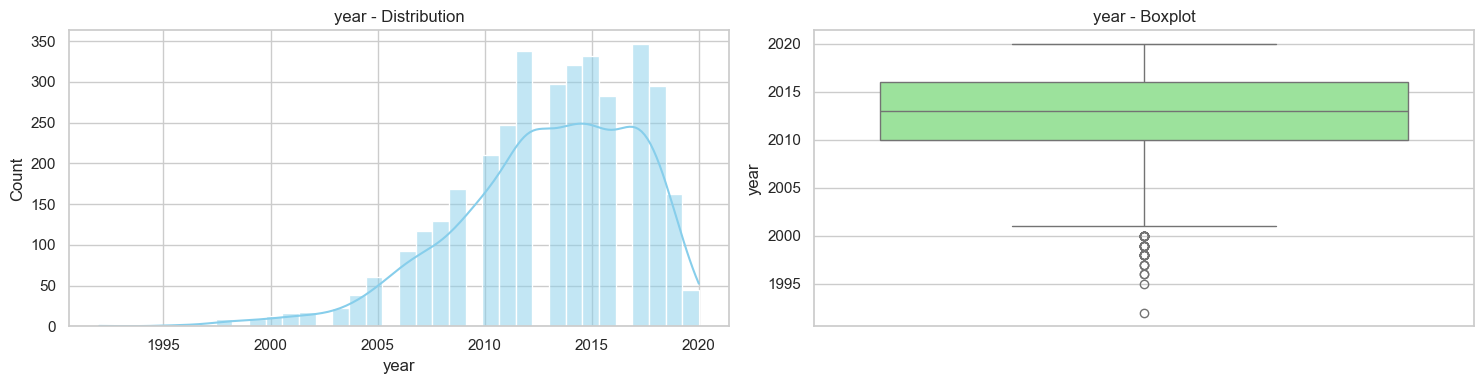

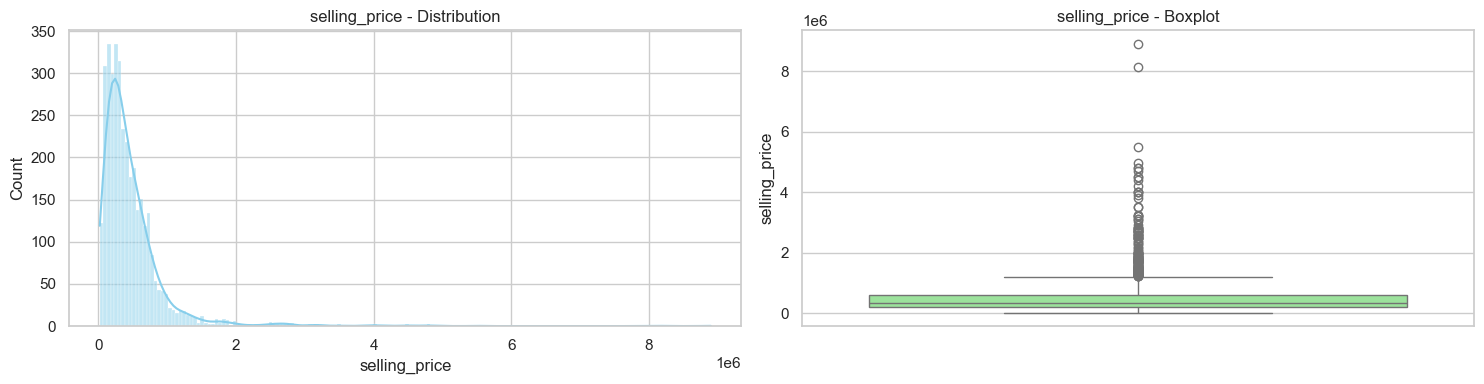

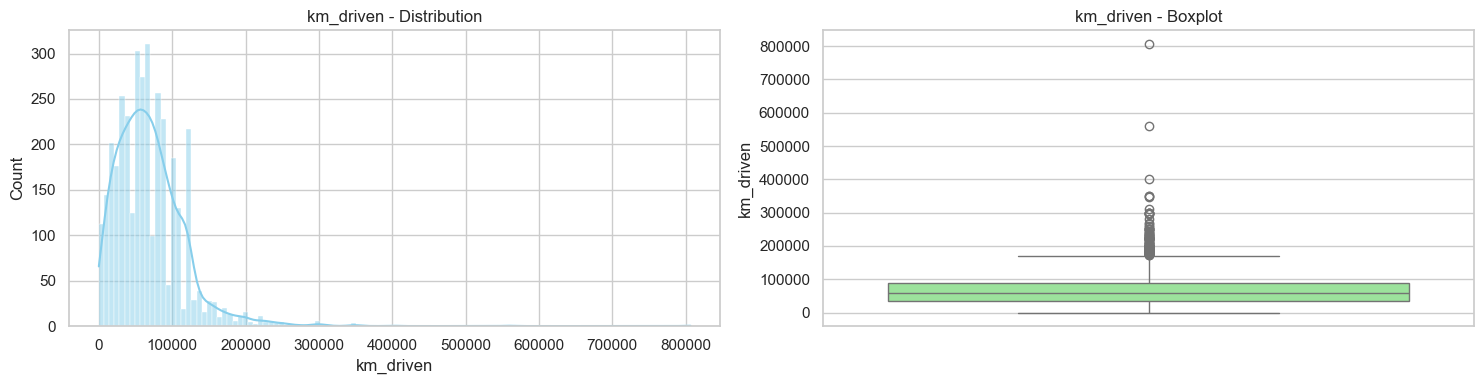

In [11]:
# Numerical features
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)

for feature in numerical_features:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    
    # Histogram with KDE
    sns.histplot(pre_working_cleaned[feature], kde=True, ax=axes[0], color="skyblue")
    axes[0].set_title(f"{feature} - Distribution")
    
    # Boxplot
    sns.boxplot(pre_working_cleaned[feature], ax=axes[1], color="lightgreen")
    axes[1].set_title(f"{feature} - Boxplot")
    
    plt.tight_layout()
    plt.show()

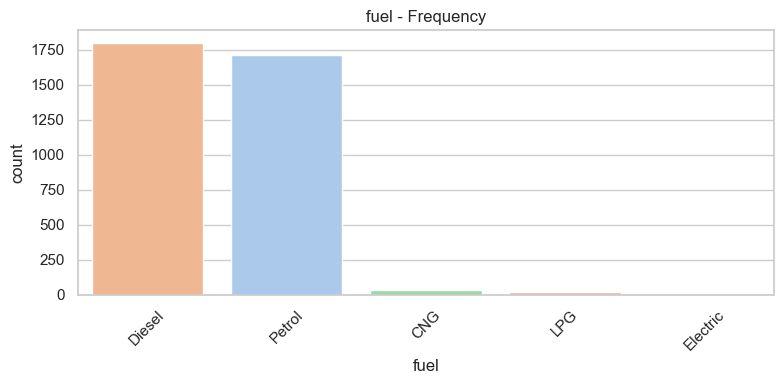

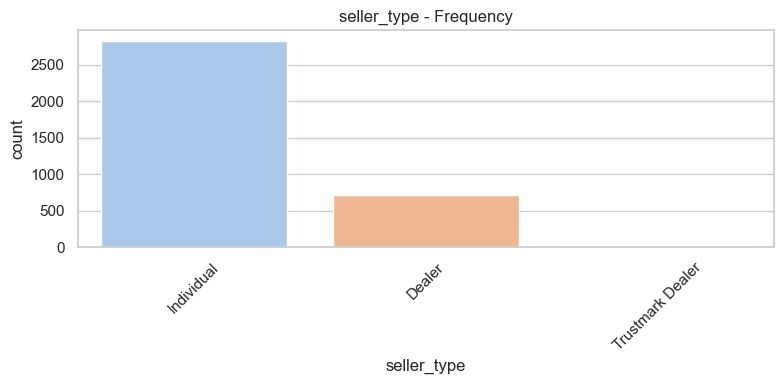

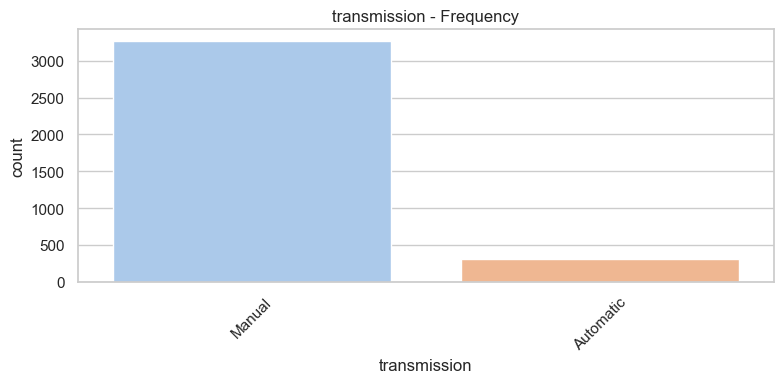

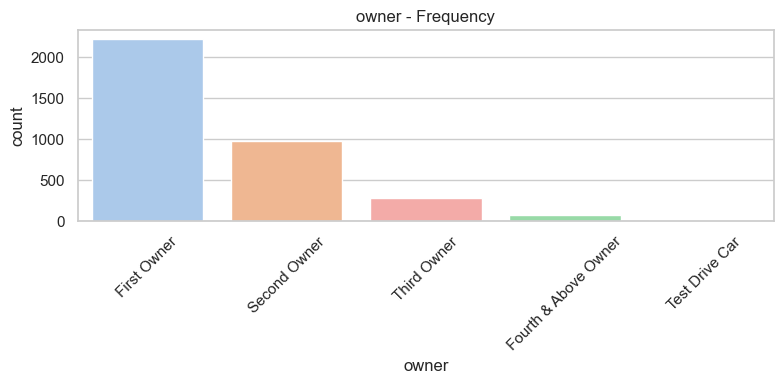

In [12]:
# categorical features
categorical_features = [col for col in categorical_features if col != "name"]

for col in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=pre_working_cleaned, x=col, hue=col, order=pre_working_cleaned[col].value_counts().index, palette="pastel")
    plt.title(f"{col} - Frequency")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

---

**Numerical Features**

- `selling_price` is highly **right-skewed**, indicating that most vehicles are priced under ₹1,000,000 with a few high-value outliers.
- `km_driven` is also **right-skewed**, suggesting that the majority of cars have moderate mileage, but some have driven very high distances.
- `year` shows that most vehicles are relatively new (2005–2020), with very few older entries.

**Observation**: Skewed features require transformation (e.g., log) during modeling.

---

**Categorical Features**

- `fuel` is dominated by Petrol and Diesel cars; CNG, LPG, and Electric vehicles are rare.
- `seller_type` is mostly "Individual", with fewer "Dealer" and very few "Trustmark Dealer".
- `transmission` is heavily biased toward Manual cars.
- `owner` shows that most listings are for First or Second Owner vehicles; higher-owner and test-drive cars are rare.

**Observation**: There is **imbalance** in several categorical features. Rare categories should be monitored during encoding/modeling to avoid introducing noise.

#### Bivariate Analysis

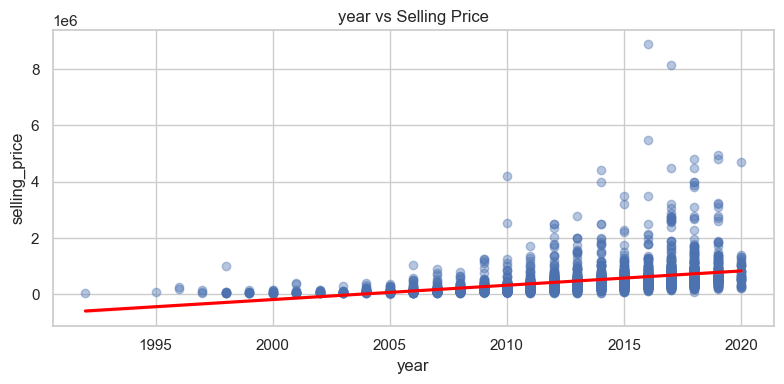

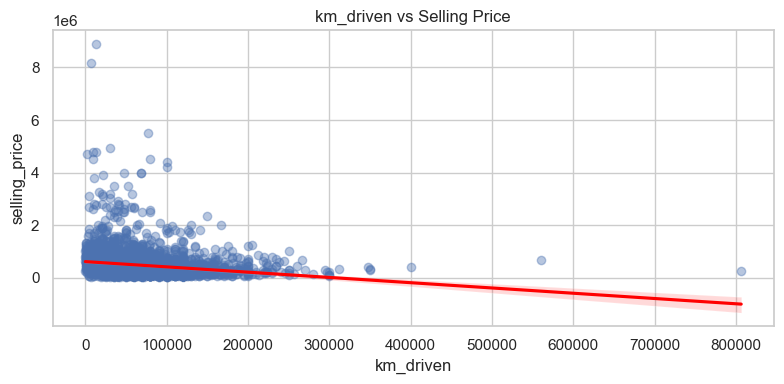

In [13]:
# numerical vs target
numerical_vs_target = [col for col in pre_working_cleaned.select_dtypes(exclude="object").columns if col != "selling_price"]

for feature in numerical_vs_target:
    plt.figure(figsize=(8, 4))
    sns.regplot(data=pre_working_cleaned, x=feature, y="selling_price", scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
    plt.title(f"{feature} vs Selling Price")
    plt.tight_layout()
    plt.show()

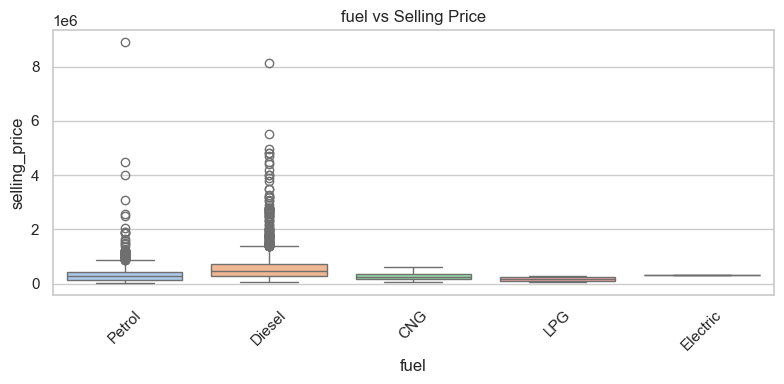

Median selling price by fuel:
fuel
Diesel      475000.0
Electric    310000.0
Petrol      260000.0
CNG         229999.0
LPG         180000.0
Name: selling_price, dtype: float64

--------------------------------------------------



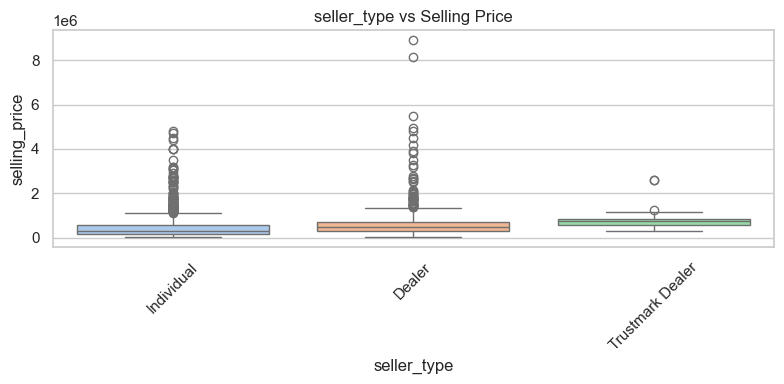

Median selling price by seller_type:
seller_type
Trustmark Dealer    750000.0
Dealer              484999.0
Individual          303500.0
Name: selling_price, dtype: float64

--------------------------------------------------



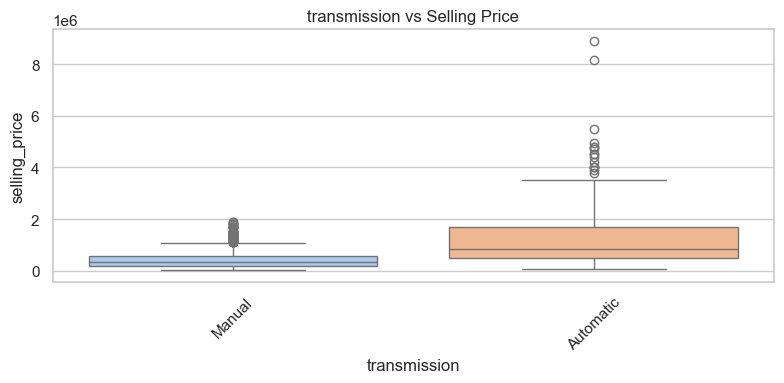

Median selling price by transmission:
transmission
Automatic    855000.0
Manual       325000.0
Name: selling_price, dtype: float64

--------------------------------------------------



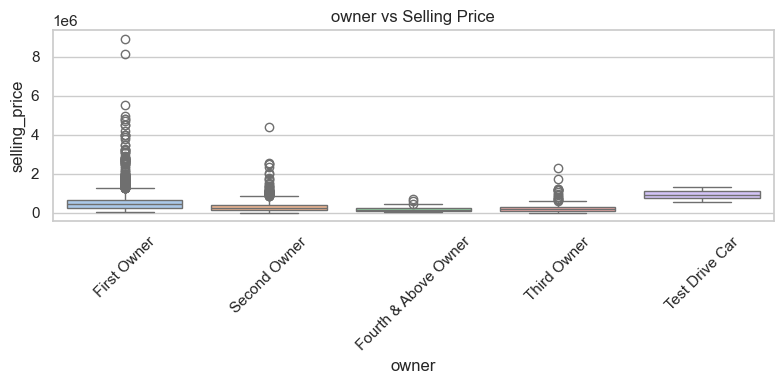

Median selling price by owner:
owner
Test Drive Car          894999.0
First Owner             450000.0
Second Owner            267000.0
Third Owner             190000.0
Fourth & Above Owner    138000.0
Name: selling_price, dtype: float64

--------------------------------------------------



In [14]:
# categorical vs target
for col in categorical_features:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(data=pre_working_cleaned, x=col, hue=col, y="selling_price", palette="pastel")
    plt.title(f"{col} vs Selling Price")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print(f"Median selling price by {col}:")
    print(pre_working_cleaned.groupby(col)["selling_price"].median().sort_values(ascending=False).round(0))
    print("\n" + "-"*50 + "\n")

---

**Numerical Features**

- **`km_driven` vs `selling_price`**
  - A weak negative relationship is observed.
  - Cars with higher mileage generally sell for lower prices, but with significant variability.

- **`year` vs `selling_price`**
  - Strong positive trend: newer cars tend to sell at higher prices.
  - This is likely one of the most important predictors in the dataset.

---

**Categorical Features**

- **`fuel`**
  - Diesel vehicles tend to have the highest **median** resale price.
  - CNG, LPG, and Electric categories have fewer entries and lower median prices.

- **`seller_type`**
  - Dealer and Trustmark Dealer listings show higher **median** prices than Individual sellers.

- **`transmission`**
  - Automatic cars have higher **median** prices, possibly due to their presence in newer or premium models.

- **`owner`**
  - Cars with fewer previous owners (especially First Owner) have significantly higher **median** resale value.
  - A clear decline in price is visible as the ownership count increases.

---


#### Outlier Detection

In [15]:
# IQR Method

Q1 = pre_working_cleaned["selling_price"].quantile(0.25)
Q3 = pre_working_cleaned["selling_price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = pre_working_cleaned[(pre_working_cleaned["selling_price"] < lower_bound) | (pre_working_cleaned["selling_price"] > upper_bound)]

# Number of outliers
num_outliers = outliers.shape[0]
num_total = pre_working_cleaned.shape[0]
percent_outliers = round((num_outliers / num_total) * 100, 2)

num_outliers, percent_outliers

(170, 4.75)

In [16]:
pre_working_cleaned["is_outlier"] = pre_working_cleaned["selling_price"].apply(lambda x: 1 if (x < lower_bound or x > upper_bound) else 0)
pre_working_cleaned["is_outlier"].value_counts()

is_outlier
0    3407
1     170
Name: count, dtype: int64

In [17]:
pre_working_cleaned.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,is_outlier
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,0
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,0
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,0
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,0
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,0


#### Multicollinearity

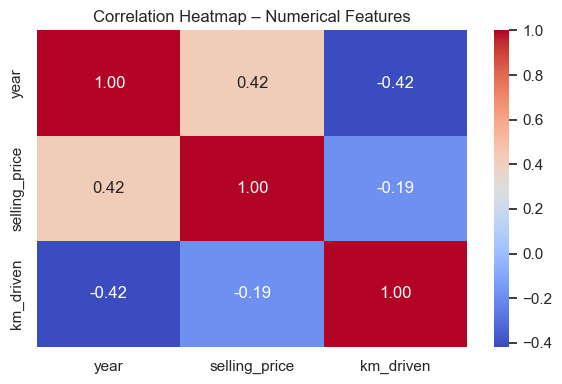

In [18]:
corr_matrix = pre_working_cleaned[numerical_features].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap – Numerical Features")
plt.tight_layout()
plt.show()

- There is **no strong multicollinearity** between the numerical features.  
- All correlation values are **well below 0.95**, which is the common threshold for multicollinearity concern in regression.  
- Therefore, all numerical features can be retained for modeling without risk of linear redundancy.

#### Skewness Of Numeric Features

Skewness of Numeric Features:

selling_price            :  5.454 → right-skewed
km_driven                :  2.549 → right-skewed
year                     : -0.786 


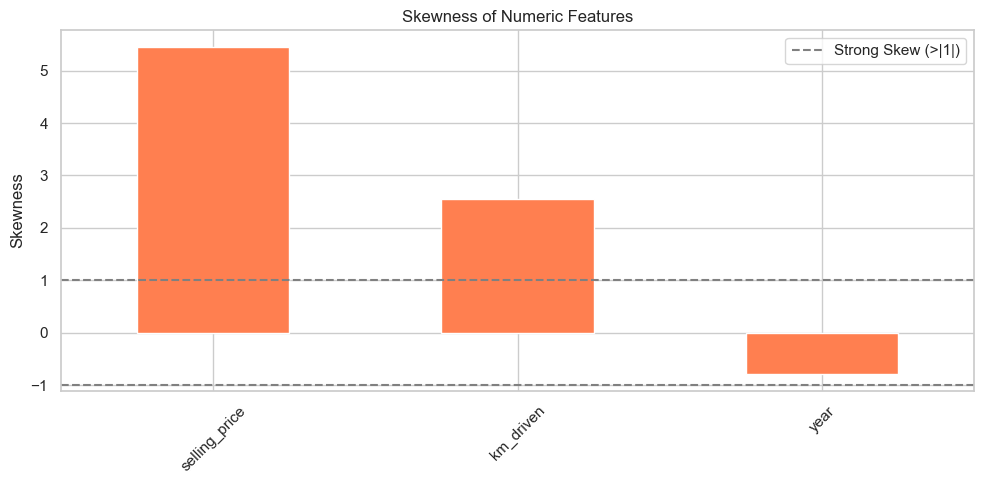

In [19]:
skewness_values = pre_working_cleaned[numerical_features].skew().sort_values(ascending=False)

print("Skewness of Numeric Features:\n")
for feature, skew in skewness_values.round(3).items():
    direction = "→ right-skewed" if skew > 1 else ("← left-skewed" if skew < -1 else "")
    print(f"{feature:25}: {skew:>6} {direction}")


plt.figure(figsize=(10, 5))
skewness_values.plot(kind="bar", color="coral")
plt.axhline(1, color="gray", linestyle="--", label="Strong Skew (>|1|)")
plt.axhline(-1, color="gray", linestyle="--")
plt.title("Skewness of Numeric Features")
plt.ylabel("Skewness")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### LogTransform for skewed data

In [20]:
pre_working_cleaned["log_selling_price"] = np.log1p(pre_working_cleaned["selling_price"])
pre_working_cleaned["log_km_driven"] = np.log1p(pre_working_cleaned["km_driven"])

pre_working_cleaned[["selling_price", "log_selling_price", "km_driven", "log_km_driven"]].head()

,selling_price,log_selling_price,km_driven,log_km_driven
0,60000,11.002117,70000,11.156265
1,135000,11.813037,50000,10.819798
2,600000,13.304687,100000,11.512935
3,250000,12.429220,46000,10.736418
4,450000,13.017005,141000,11.856522


### 4. Create regression models and some sort of hyperparameter optimization (Bayesian Optimizer, Random search, grid search)

In [21]:
working_df = pre_working_cleaned.copy()

In [22]:
working_df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,is_outlier,log_selling_price,log_km_driven
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,0,11.002117,11.156265
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,0,11.813037,10.819798
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,0,13.304687,11.512935
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,0,12.429220,10.736418
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,0,13.017005,11.856522


#### Encoding categorical features

Before training the baseline model, I need to convert categorical features into numerical format, since regression algorithms cannot handle raw text categories.

I will use:
- **One-Hot Encoding** for nominal and binary categorical features: `fuel`, `seller_type`, `transmission`
- **Ordinal Encoding** for the `owner` feature, which has a clear ranked order (from "Test Drive Car" to "First Owner")

This step ensures that all input features are in a format suitable for regression models while preserving the meaning of the original categories.

In [23]:
categorical_onehot = ['fuel', 'seller_type', 'transmission']

ordinal_map = {
    "Test Drive Car": 0,
    "Fourth & Above Owner": 1,
    "Third Owner": 2,
    "Second Owner": 3,
    "First Owner": 4
}
working_df["owner_encoded"] = working_df["owner"].map(ordinal_map)

In [24]:
working_df_encoded = pd.get_dummies(working_df, columns=categorical_onehot, drop_first=True, dtype=int)

In [25]:
working_df_encoded.head()

,name,year,selling_price,km_driven,owner,is_outlier,log_selling_price,log_km_driven,owner_encoded,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
0,Maruti 800 AC,2007,60000,70000,First Owner,0,11.002117,11.156265,4,0,0,0,1,1,0,1
1,Maruti Wagon R LXI Minor,2007,135000,50000,First Owner,0,11.813037,10.819798,4,0,0,0,1,1,0,1
2,Hyundai Verna 1.6 SX,2012,600000,100000,First Owner,0,13.304687,11.512935,4,1,0,0,0,1,0,1
3,Datsun RediGO T Option,2017,250000,46000,First Owner,0,12.429220,10.736418,4,0,0,0,1,1,0,1
4,Honda Amaze VX i-DTEC,2014,450000,141000,Second Owner,0,13.017005,11.856522,3,1,0,0,0,1,0,1


#### Creating a Baseline Models

In [26]:
df_with_outliers = working_df_encoded.copy()

In [27]:
df_with_outliers.shape

(3577, 16)

In [28]:
df_no_outliers = working_df_encoded[working_df_encoded["is_outlier"] == 0].copy()

In [29]:
df_no_outliers.shape

(3407, 16)

In [30]:
feature_cols = ["year", "log_km_driven", "owner_encoded"] + [
    col for col in df_with_outliers.columns
    if col.startswith("fuel_") or col.startswith("seller_type_") or col.startswith("transmission_")]

feature_cols

['year',
 'log_km_driven',
 'owner_encoded',
 'fuel_Diesel',
 'fuel_Electric',
 'fuel_LPG',
 'fuel_Petrol',
 'seller_type_Individual',
 'seller_type_Trustmark Dealer',
 'transmission_Manual']

In [31]:
X_with_outliers = df_with_outliers[feature_cols]
y_with_outliers = df_with_outliers["log_selling_price"]

X_no_outliers = df_no_outliers[feature_cols]
y_no_outliers = df_no_outliers["log_selling_price"]

results = []

In [32]:
def evaluate_model(model, X, y, model_name, version="Baseline", outliers="Included", scaling="No", tuned_params=None):
    """
    Trains and evaluates a regression model using train/test split.

    Parameters:
    - model: regression model instance (e.g. LinearRegression, DecisionTreeRegressor)
    - X: DataFrame with feature variables
    - y: Series with target variable (log_selling_price)
    - model_name: name of the model to track in the results table
    - version: model version label (e.g. 'Baseline', 'Tuned')
    - outliers: specifies whether outliers are included ('Included'/'Removed')
    - scaling: 'Yes' to apply StandardScaler, otherwise 'No'
    - tuned_params: list of tuned parameter names to include in "Details" (optional)

    Returns:
    - Dictionary of evaluation metrics (MAE, RMSE, R2)
    - Appends metrics dictionary to global `results` list (only if not already present)
    """

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

    if scaling == "Yes":
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if tuned_params:
        details = {k: v for k, v in model.get_params().items() if k in tuned_params}
    else:
        details = str(model)

    metrics = {
        "Model": model_name,
        "Version": version,
        "Outliers": outliers,
        "Scaling": scaling,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
        "Details": details
    }

    if metrics not in results:
        results.append(metrics)

    return metrics

In [33]:
model_configs = [
    # Format: (Model instance, Model name, Outliers, Scaling)

    # Without Outliers
    (LinearRegression(), "Linear Regression", "Removed", "Yes"),
    (Ridge(), "Ridge Regression", "Removed", "Yes"),
    (Lasso(), "Lasso Regression", "Removed", "Yes"),
    (ElasticNet(), "ElasticNet Regression", "Removed", "Yes"),
    (KNeighborsRegressor(), "KNN Regressor", "Removed", "Yes"),
    (SVR(), "SVR", "Removed", "Yes"),
    (RandomForestRegressor(random_state=42), "Random Forest", "Removed", "No"),
    (DecisionTreeRegressor(random_state=42), "Decision Tree", "Removed", "No"),

    # With Outliers
    (LinearRegression(), "Linear Regression", "Included", "Yes"),
    (Ridge(), "Ridge Regression", "Included", "Yes"),
    (Lasso(), "Lasso Regression", "Included", "Yes"),
    (ElasticNet(), "ElasticNet Regression", "Included", "Yes"),
    (KNeighborsRegressor(), "KNN Regressor", "Included", "Yes"),
    (SVR(), "SVR", "Included", "Yes"),
    (RandomForestRegressor(random_state=42), "Random Forest", "Included", "No"),
    (DecisionTreeRegressor(random_state=42), "Decision Tree", "Included", "No")
]

for model, name, outliers, scaling in model_configs:
    X_used = X_no_outliers if outliers == "Removed" else X_with_outliers
    y_used = y_no_outliers if outliers == "Removed" else y_with_outliers

    evaluate_model(
        model=model,
        X=X_used,
        y=y_used,
        model_name=name,
        version="Baseline",
        outliers=outliers,
        scaling=scaling
    )

pd.DataFrame(results)

,Model,Version,Outliers,Scaling,MAE,RMSE,R2,Details
0,Linear Regression,Baseline,Removed,Yes,0.339421,0.443660,0.626349,LinearRegression()
1,Ridge Regression,Baseline,Removed,Yes,0.339452,0.443656,0.626356,Ridge()
2,Lasso Regression,Baseline,Removed,Yes,0.585152,0.725960,-0.000441,Lasso()
3,ElasticNet Regression,Baseline,Removed,Yes,0.574082,0.711600,0.038748,ElasticNet()
4,KNN Regressor,Baseline,Removed,Yes,0.365012,0.477239,0.567648,KNeighborsRegressor()
5,SVR,Baseline,Removed,Yes,0.337166,0.442601,0.628131,SVR()
6,Random Forest,Baseline,Removed,No,0.369965,0.485779,0.552037,RandomForestRegressor(random_state=42)
7,Decision Tree,Baseline,Removed,No,0.426567,0.565030,0.393949,DecisionTreeRegressor(random_state=42)
8,Linear Regression,Baseline,Included,Yes,0.359067,0.468292,0.678947,LinearRegression()
9,Ridge Regression,Baseline,Included,Yes,0.359037,0.468268,0.678980,Ridge()


In [34]:
df_results = pd.DataFrame(results)

best_variants = (
    df_results.sort_values("R2", ascending=False)
    .groupby(["Model", "Outliers"], as_index=False)
    .first()
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)

best_variants_sorted = best_variants.sort_values("R2", ascending=False).reset_index(drop=True)

best_variants_sorted

,Model,Outliers,Version,Scaling,MAE,RMSE,R2,Details
0,SVR,Included,Baseline,Yes,0.350684,0.463632,0.685306,SVR()
1,Ridge Regression,Included,Baseline,Yes,0.359037,0.468268,0.678980,Ridge()
2,Linear Regression,Included,Baseline,Yes,0.359067,0.468292,0.678947,LinearRegression()
3,KNN Regressor,Included,Baseline,Yes,0.383128,0.498052,0.636846,KNeighborsRegressor()
4,Random Forest,Included,Baseline,No,0.384099,0.500057,0.633916,RandomForestRegressor(random_state=42)
5,SVR,Removed,Baseline,Yes,0.337166,0.442601,0.628131,SVR()
6,Ridge Regression,Removed,Baseline,Yes,0.339452,0.443656,0.626356,Ridge()
7,Linear Regression,Removed,Baseline,Yes,0.339421,0.443660,0.626349,LinearRegression()
8,KNN Regressor,Removed,Baseline,Yes,0.365012,0.477239,0.567648,KNeighborsRegressor()
9,Random Forest,Removed,Baseline,No,0.369965,0.485779,0.552037,RandomForestRegressor(random_state=42)


- All models perform **better with outliers included**.
- The difference in **R² is consistently in favor** of the models trained on the full dataset.
- **RMSE and MAE values** remain within acceptable bounds, suggesting that outliers do not introduce significant instability.

---

I will continue working with the **version of the dataset that includes outliers**.

#### Hyperparameter optimization

In [36]:
# BayesSearchCV  Random Forest Regressor
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_with_outliers, y_with_outliers, test_size=0.25, random_state=42
)

param_space_rf = {
    "n_estimators": Integer(100, 300),
    "max_depth": Integer(5, 20),
    "min_samples_split": Integer(2, 10),
    "min_samples_leaf": Integer(1, 4),
    "max_features": Categorical(["sqrt", "log2"])
}

rf_bayes_search = BayesSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    search_spaces=param_space_rf,
    n_iter=20,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=0
)

rf_bayes_search.fit(X_train_rf, y_train_rf)

evaluate_model(
    model=rf_bayes_search.best_estimator_,
    X=X_with_outliers,
    y=y_with_outliers,
    model_name="Random Forest",
    version="Tuned - Bayesian",
    outliers="Included",
    scaling="No",
    tuned_params=["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf", "max_features"]
)

{'Model': 'Random Forest',
 'Version': 'Tuned - Bayesian',
 'Outliers': 'Included',
 'Scaling': 'No',
 'MAE': 0.3526330546014484,
 'RMSE': np.float64(0.461839233720553),
 'R2': 0.687734297141233,
 'Details': {'max_depth': 10,
  'max_features': 'log2',
  'min_samples_leaf': 4,
  'min_samples_split': 5,
  'n_estimators': 254}}

In [35]:
# BayesSearchCV SVR
X_train, X_test, y_train, y_test = train_test_split(
    X_with_outliers, y_with_outliers, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_space = {
    "C": Real(1e-2, 1e3, prior="log-uniform"),
    "epsilon": Real(0.01, 1.0, prior="uniform"),
    "kernel": Categorical(["rbf", "linear"])
}

bayes_search = BayesSearchCV(
    estimator=SVR(),
    search_spaces=param_space,
    n_iter=30,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=0
)

bayes_search.fit(X_train_scaled, y_train)

evaluate_model(
    model=bayes_search.best_estimator_,
    X=X_with_outliers,
    y=y_with_outliers,
    model_name="SVR",
    version="Tuned - Bayesian",
    outliers="Included",
    scaling="Yes",
    tuned_params=["C", "epsilon", "kernel"]
)

{'Model': 'SVR',
 'Version': 'Tuned - Bayesian',
 'Outliers': 'Included',
 'Scaling': 'Yes',
 'MAE': 0.3507513715464289,
 'RMSE': np.float64(0.46218873803409694),
 'R2': 0.687261494060842,
 'Details': {'C': 1.7729223238234193,
  'epsilon': 0.21708122134722607,
  'kernel': 'rbf'}}

In [37]:
# BayesSearchCV KNN
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_with_outliers, y_with_outliers, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train_knn_scaled = scaler.fit_transform(X_train_knn)
X_test_knn_scaled = scaler.transform(X_test_knn)

param_space_knn = {
    "n_neighbors": Integer(3, 20),
    "weights": Categorical(["uniform", "distance"]),
    "p": Integer(1, 2)  # 1=Manhattan, 2=Euclidean
}

knn_bayes_search = BayesSearchCV(
    estimator=KNeighborsRegressor(),
    search_spaces=param_space_knn,
    n_iter=20,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=0
)

knn_bayes_search.fit(X_train_knn_scaled, y_train_knn)

evaluate_model(
    model=knn_bayes_search.best_estimator_,
    X=X_with_outliers,
    y=y_with_outliers,
    model_name="KNN Regressor",
    version="Tuned - Bayesian",
    outliers="Included",
    scaling="Yes",
    tuned_params=["n_neighbors", "weights", "p"]
)

C:\Users\jasmi\AppData\Local\Programs\Python\Python313\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(20), np.int64(1), np.str_('uniform')] before, using random point [np.int64(4), np.int64(1), 'distance']
  warnings.warn(


{'Model': 'KNN Regressor',
 'Version': 'Tuned - Bayesian',
 'Outliers': 'Included',
 'Scaling': 'Yes',
 'MAE': 0.3626123234031879,
 'RMSE': np.float64(0.47391605859664293),
 'R2': 0.6711896427352158,
 'Details': {'n_neighbors': 20, 'p': 1, 'weights': 'uniform'}}

In [38]:
# Randomized SearchCV SVR
X_train, X_test, y_train, y_test = train_test_split(X_with_outliers, y_with_outliers, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svr_param_dist = {
    "C": np.logspace(-2, 3, 10),
    "epsilon": np.linspace(0.01, 1.0, 10),
    "kernel": ["rbf", "linear", "poly", "sigmoid"]
}

random_search = RandomizedSearchCV(
    estimator=SVR(),
    param_distributions=svr_param_dist,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train_scaled, y_train)

evaluate_model(
    model=random_search.best_estimator_,
    X=X_with_outliers,
    y=y_with_outliers,
    model_name="SVR",
    version="Tuned - Random",
    outliers="Included",
    scaling="Yes",
    tuned_params=["C", "epsilon", "kernel"]
)

{'Model': 'SVR',
 'Version': 'Tuned - Random',
 'Outliers': 'Included',
 'Scaling': 'Yes',
 'MAE': 0.3555735906796222,
 'RMSE': np.float64(0.46726695358609976),
 'R2': 0.6803514238287474,
 'Details': {'C': np.float64(0.464158883361278),
  'epsilon': np.float64(0.34),
  'kernel': 'rbf'}}

In [39]:
# Grid SearchCV SVR
svr_param_grid = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.01, 0.1, 0.2, 0.5],
    "kernel": ["rbf", "linear"]
}

grid_search = GridSearchCV(
    estimator=SVR(),
    param_grid=svr_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

evaluate_model(
    model=grid_search.best_estimator_,
    X=X_with_outliers,
    y=y_with_outliers,
    model_name="SVR",
    version="Tuned - Grid",
    outliers="Included",
    scaling="Yes",
    tuned_params=["C", "epsilon", "kernel"]
)

{'Model': 'SVR',
 'Version': 'Tuned - Grid',
 'Outliers': 'Included',
 'Scaling': 'Yes',
 'MAE': 0.35203293870706054,
 'RMSE': np.float64(0.46417377204677635),
 'R2': 0.6845693917395783,
 'Details': {'C': 1, 'epsilon': 0.2, 'kernel': 'rbf'}}

In [40]:
# RandomizedSearchCV Random Forest
param_dist_rf = {
    "n_estimators": [100, 150, 200],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

rf_random.fit(X_train_rf, y_train_rf)

evaluate_model(
    model=rf_random.best_estimator_,
    X=X_with_outliers,
    y=y_with_outliers,
    model_name="Random Forest",
    version="Tuned - Random",
    outliers="Included",
    scaling="No",
    tuned_params=["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf", "max_features"]
)

{'Model': 'Random Forest',
 'Version': 'Tuned - Random',
 'Outliers': 'Included',
 'Scaling': 'No',
 'MAE': 0.3545643911889915,
 'RMSE': np.float64(0.46268866811015935),
 'R2': 0.6865845760428251,
 'Details': {'max_depth': 10,
  'max_features': 'sqrt',
  'min_samples_leaf': 2,
  'min_samples_split': 5,
  'n_estimators': 150}}

In [41]:
# GridSearchCV Random Forest
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train_rf, y_train_rf)

evaluate_model(
    model=rf_grid.best_estimator_,
    X=X_with_outliers,
    y=y_with_outliers,
    model_name="Random Forest",
    version="Tuned - Grid",
    outliers="Included",
    scaling="No",
    tuned_params=["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf", "max_features"]
)

{'Model': 'Random Forest',
 'Version': 'Tuned - Grid',
 'Outliers': 'Included',
 'Scaling': 'No',
 'MAE': 0.35399666081553294,
 'RMSE': np.float64(0.4623558186530953),
 'R2': 0.6870353440772144,
 'Details': {'max_depth': 10,
  'max_features': 'sqrt',
  'min_samples_leaf': 2,
  'min_samples_split': 5,
  'n_estimators': 200}}

In [42]:
# RandomizedSearchCV KNN
param_dist_knn = {
    "n_neighbors": list(range(3, 21)),
    "weights": ["uniform", "distance"],
    "p": [1, 2]  # Manhattan, Euclidean
}

knn_random = RandomizedSearchCV(
    estimator=KNeighborsRegressor(),
    param_distributions=param_dist_knn,
    n_iter=15,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

knn_random.fit(X_train_knn_scaled, y_train_knn)

evaluate_model(
    model=knn_random.best_estimator_,
    X=X_with_outliers,
    y=y_with_outliers,
    model_name="KNN Regressor",
    version="Tuned - Random",
    outliers="Included",
    scaling="Yes",
    tuned_params=["n_neighbors", "weights", "p"]
)

{'Model': 'KNN Regressor',
 'Version': 'Tuned - Random',
 'Outliers': 'Included',
 'Scaling': 'Yes',
 'MAE': 0.36561126019975715,
 'RMSE': np.float64(0.47442233796368505),
 'R2': 0.670486738431711,
 'Details': {'n_neighbors': 16, 'p': 2, 'weights': 'uniform'}}

#### 5. Evaluate the models using proper evaluation metrics

In [206]:
# GridSearchCV за KNN
param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11, 13, 15],
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

knn_grid = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=param_grid_knn,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

knn_grid.fit(X_train_knn_scaled, y_train_knn)

evaluate_model(
    model=knn_grid.best_estimator_,
    X=X_with_outliers,
    y=y_with_outliers,
    model_name="KNN Regressor",
    version="Tuned - Grid",
    outliers="Included",
    scaling="Yes",
    tuned_params=["n_neighbors", "weights", "p"]
)

{'Model': 'KNN Regressor',
 'Version': 'Tuned - Grid',
 'Outliers': 'Included',
 'Scaling': 'Yes',
 'MAE': 0.3675636700045453,
 'RMSE': np.float64(0.476053769242016),
 'R2': 0.6682165985013586,
 'Details': {'n_neighbors': 13, 'p': 1, 'weights': 'uniform'}}

In [43]:
top_models = pd.DataFrame(results).sort_values("R2", ascending=False).head(10)
top_models

,Model,Version,Outliers,Scaling,MAE,RMSE,R2,Details
17,Random Forest,Tuned - Bayesian,Included,No,0.352633,0.461839,0.687734,"{'max_depth': 10, 'max_features': 'log2', 'min..."
16,SVR,Tuned - Bayesian,Included,Yes,0.350751,0.462189,0.687261,"{'C': 1.7729223238234193, 'epsilon': 0.2170812..."
22,Random Forest,Tuned - Grid,Included,No,0.353997,0.462356,0.687035,"{'max_depth': 10, 'max_features': 'sqrt', 'min..."
21,Random Forest,Tuned - Random,Included,No,0.354564,0.462689,0.686585,"{'max_depth': 10, 'max_features': 'sqrt', 'min..."
13,SVR,Baseline,Included,Yes,0.350684,0.463632,0.685306,SVR()
20,SVR,Tuned - Grid,Included,Yes,0.352033,0.464174,0.684569,"{'C': 1, 'epsilon': 0.2, 'kernel': 'rbf'}"
19,SVR,Tuned - Random,Included,Yes,0.355574,0.467267,0.680351,"{'C': 0.464158883361278, 'epsilon': 0.34, 'ker..."
9,Ridge Regression,Baseline,Included,Yes,0.359037,0.468268,0.678980,Ridge()
8,Linear Regression,Baseline,Included,Yes,0.359067,0.468292,0.678947,LinearRegression()
18,KNN Regressor,Tuned - Bayesian,Included,Yes,0.362612,0.473916,0.671190,"{'n_neighbors': 20, 'p': 1, 'weights': 'uniform'}"


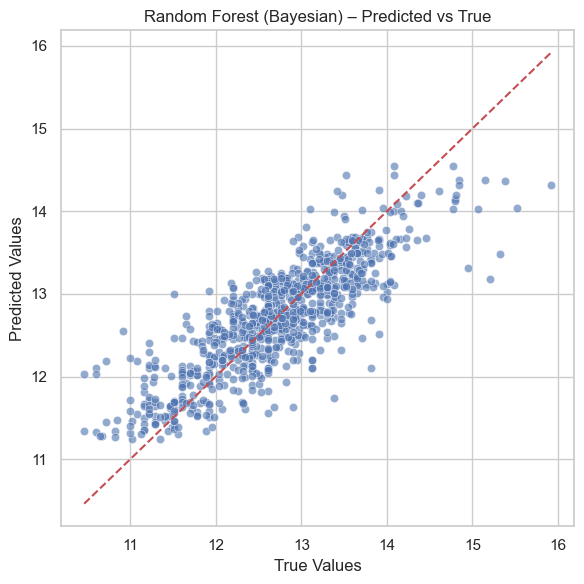

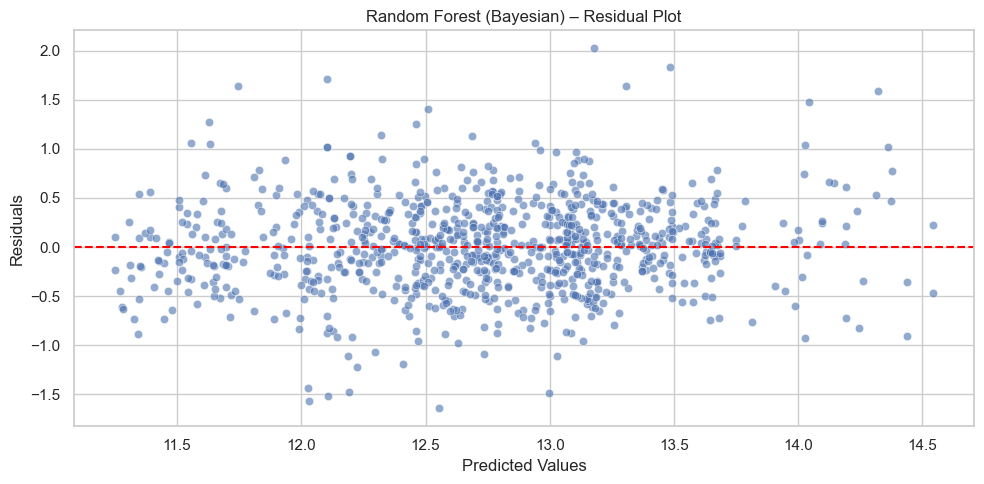

In [44]:
# No.1 Model Plots
y_pred_rf = rf_bayes_search.best_estimator_.predict(X_test_rf)

# Scatter
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test_rf, y=y_pred_rf, alpha=0.6)
plt.plot([y_test_rf.min(), y_test_rf.max()], [y_test_rf.min(), y_test_rf.max()], 'r--')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest (Bayesian) – Predicted vs True")
plt.tight_layout()
plt.show()

# Residual Plot
residuals = y_test_rf - y_pred_rf
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred_rf, y=residuals, alpha=0.6)
plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Random Forest (Bayesian) – Residual Plot")
plt.tight_layout()
plt.show()

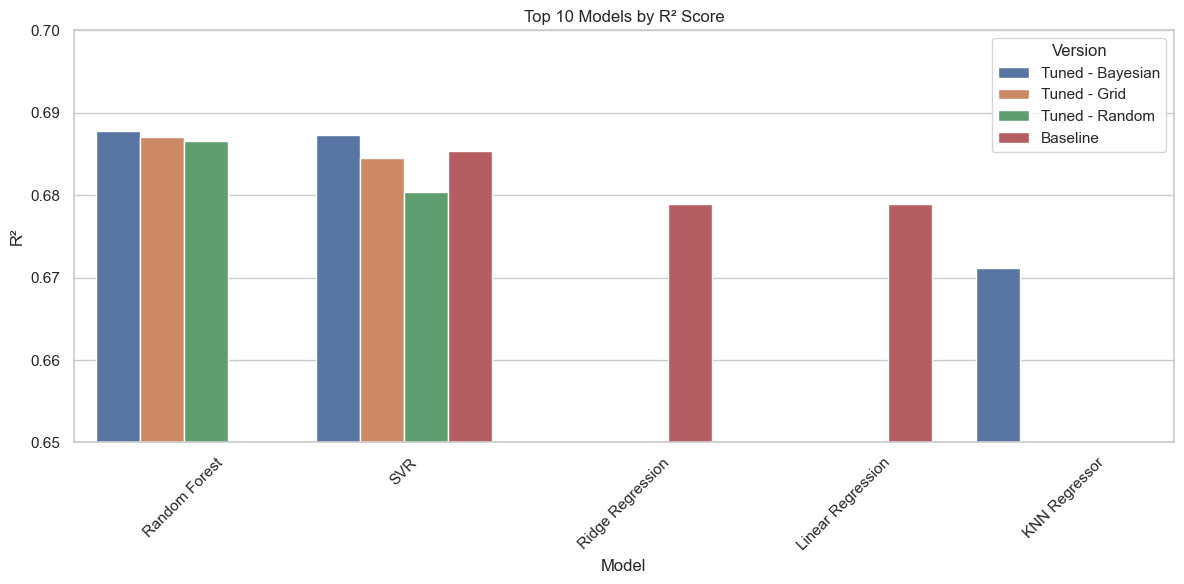

In [45]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_models, x="Model", y="R2", hue="Version")
plt.title("Top 10 Models by R² Score")
plt.ylim(0.65, 0.70)
plt.xticks(rotation=45)
plt.ylabel("R²")
plt.legend(title="Version")
plt.tight_layout()
plt.show()

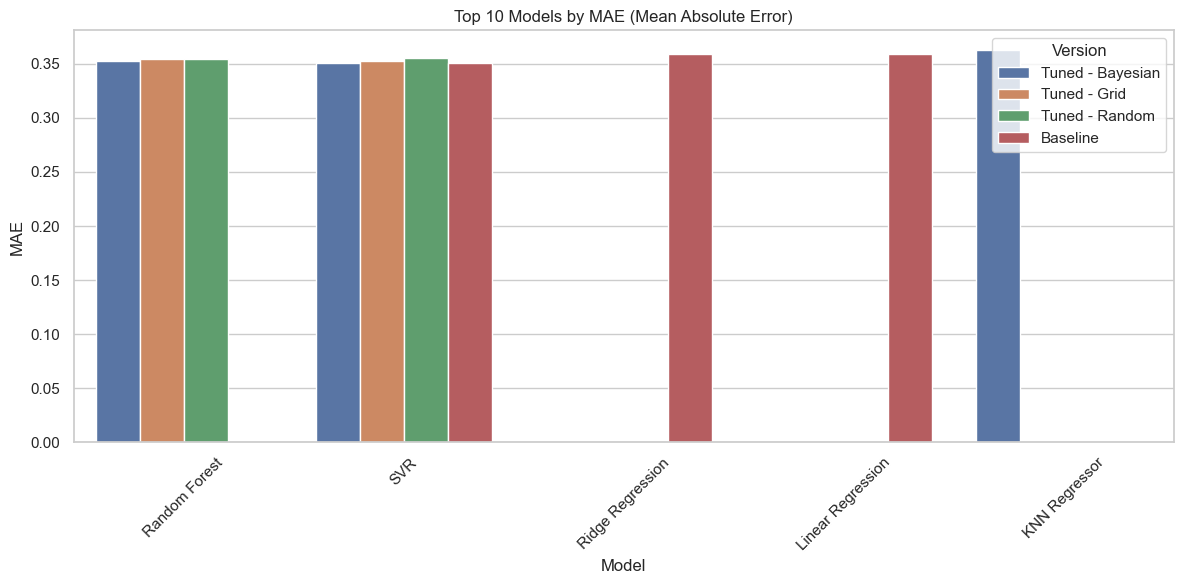

In [46]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_models, x="Model", y="MAE", hue="Version")
plt.title("Top 10 Models by MAE (Mean Absolute Error)")
plt.xticks(rotation=45)
plt.ylabel("MAE")
plt.xlabel("Model")
plt.legend(title="Version")
plt.tight_layout()
plt.show()

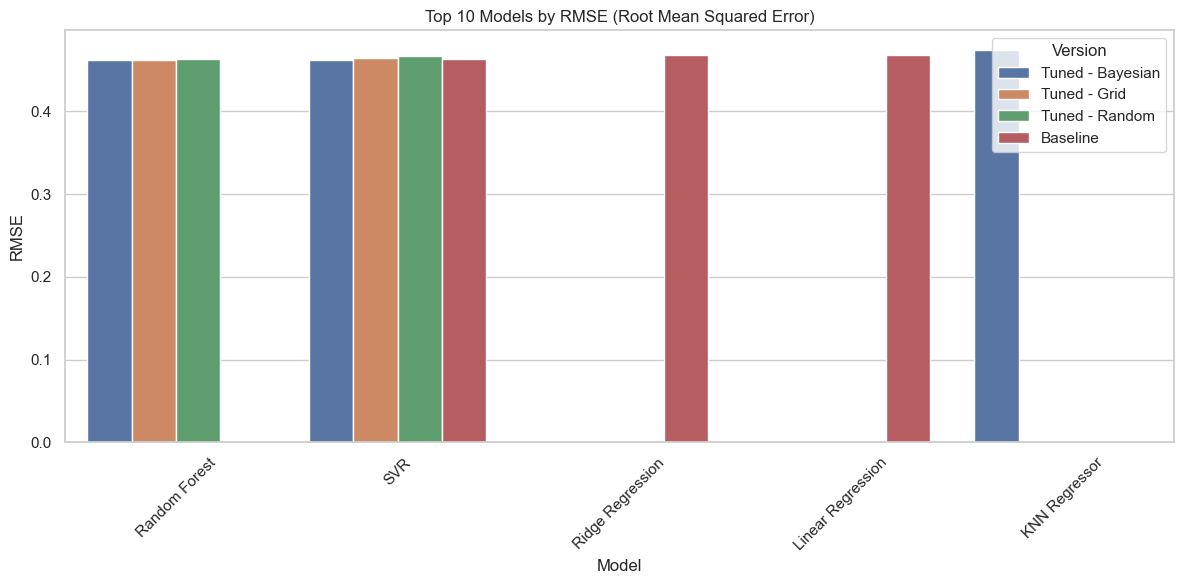

In [47]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_models, x="Model", y="RMSE", hue="Version")
plt.title("Top 10 Models by RMSE (Root Mean Squared Error)")
plt.xticks(rotation=45)
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.legend(title="Version")
plt.tight_layout()
plt.show()

#### 6. Showcase the best variant of each algorithm in a table

In [48]:
best_variants = (
    pd.DataFrame(results)
    .sort_values("R2", ascending=False)
    .groupby("Model", as_index=False)
    .first()
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)

best_variants

,Model,Version,Outliers,Scaling,MAE,RMSE,R2,Details
0,Random Forest,Tuned - Bayesian,Included,No,0.352633,0.461839,0.687734,"{'max_depth': 10, 'max_features': 'log2', 'min..."
1,SVR,Tuned - Bayesian,Included,Yes,0.350751,0.462189,0.687261,"{'C': 1.7729223238234193, 'epsilon': 0.2170812..."
2,Ridge Regression,Baseline,Included,Yes,0.359037,0.468268,0.678980,Ridge()
3,Linear Regression,Baseline,Included,Yes,0.359067,0.468292,0.678947,LinearRegression()
4,KNN Regressor,Tuned - Bayesian,Included,Yes,0.362612,0.473916,0.671190,"{'n_neighbors': 20, 'p': 1, 'weights': 'uniform'}"
5,Decision Tree,Baseline,Included,No,0.449416,0.589256,0.491664,DecisionTreeRegressor(random_state=42)
6,ElasticNet Regression,Baseline,Included,Yes,0.621448,0.793849,0.077390,ElasticNet()
7,Lasso Regression,Baseline,Included,Yes,0.649049,0.826552,-0.000191,Lasso()
